# SEAS5 trigger individual regions, additional regions
<!-- markdownlint-disable MD013 -->
Triggering in regions independently (Centre-Nord, Sahel, Boucle de Mouhoun, Sud-Ouest).

Basically a copy+paste of `seas5_trigger_individual` to include the extra regions.

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import calendar

import pandas as pd
import numpy as np
import ocha_stratus as stratus
import matplotlib.pyplot as plt

from src.constants import *
from src.utils import rp_calc

## Load data

In [3]:
engine = stratus.get_engine("prod")
pcodes = ADM1_AOI_PCODES_EXTRA
# pcodes = ADM1_AOI_PCODES

In [4]:
query = f"""
SELECT *
FROM public.polygon
WHERE pcode IN {tuple(pcodes)}
"""
df_adm = pd.read_sql(query, engine)

In [5]:
query = f"""
SELECT *
FROM public.seas5
WHERE pcode in {tuple(pcodes)}
"""
df_seas5 = pd.read_sql(
    query, engine, parse_dates=["valid_date", "issued_date"]
)

In [6]:
df_seas5 = df_seas5.merge(df_adm)

In [7]:
df_seas5["name"].unique()

array(['Sud-Ouest', 'Centre-Nord', 'Boucle du Mouhoun', 'Sahel', 'Nord'],
      dtype=object)

In [8]:
names_str = ", ".join(df_seas5["name"].unique())

## Plot seasonality

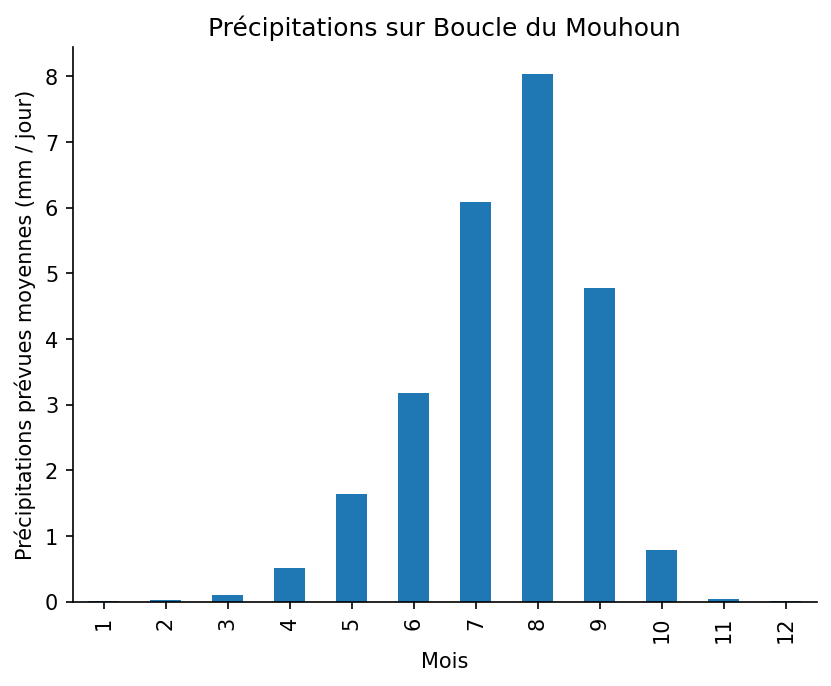

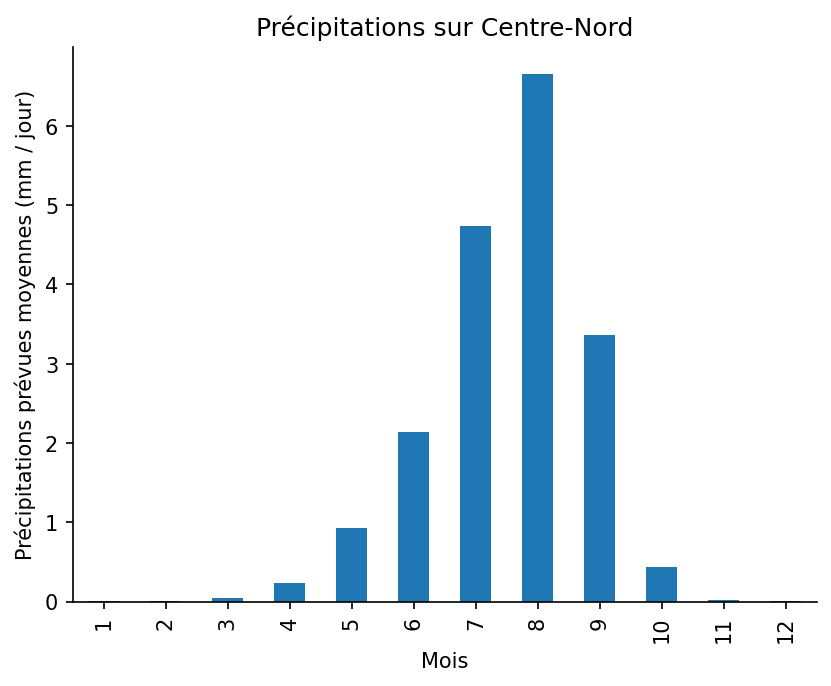

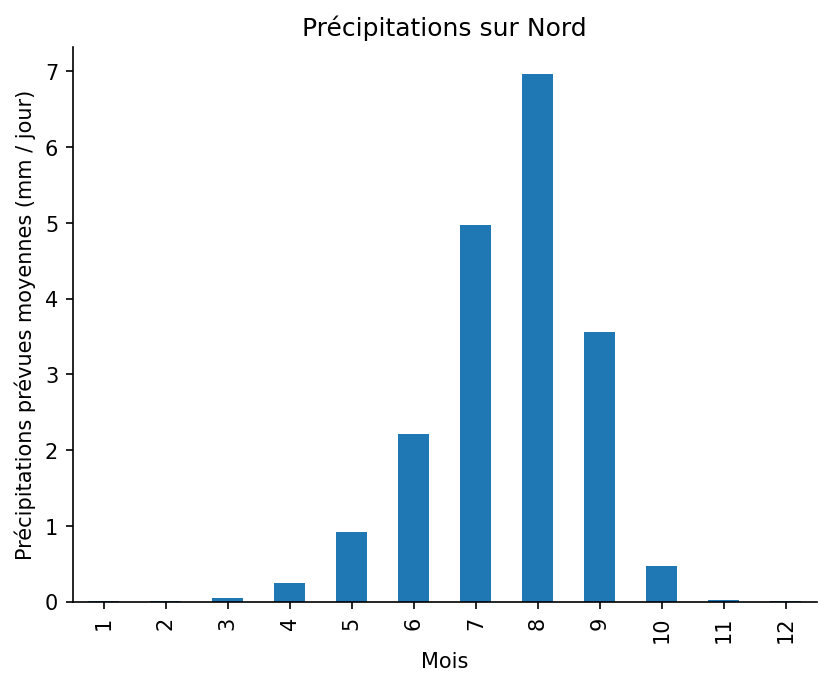

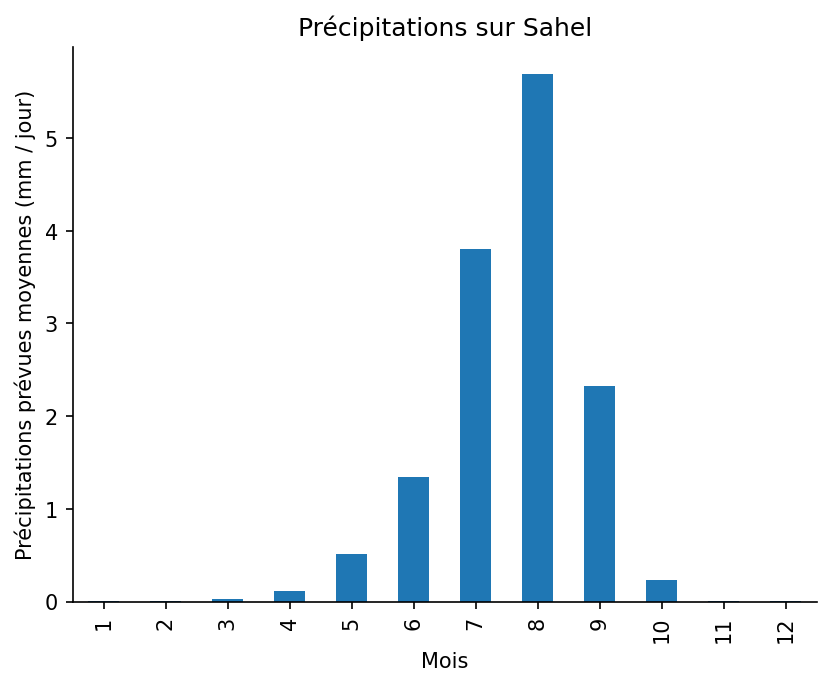

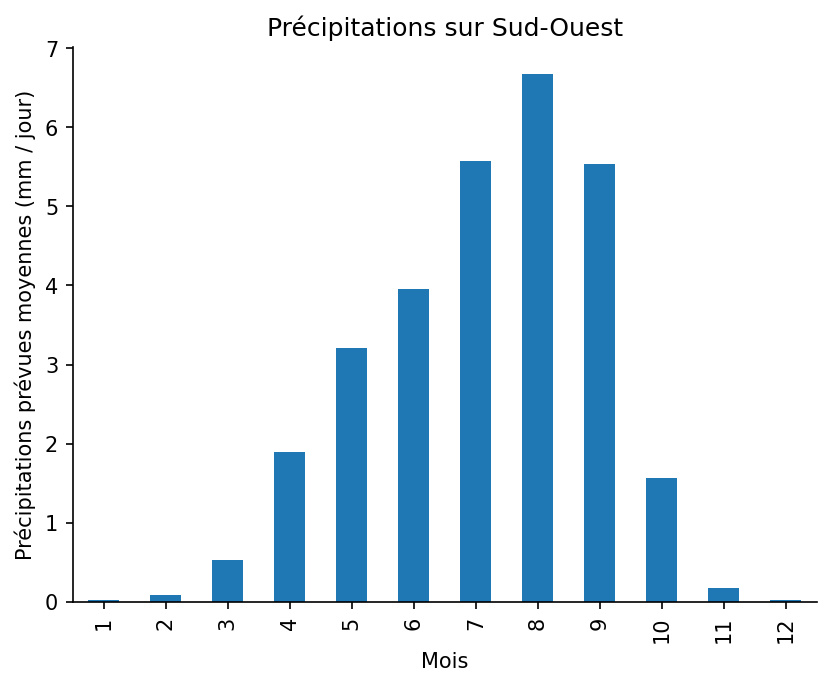

In [9]:
for name, group in df_seas5.groupby("name"):
    fig, ax = plt.subplots(dpi=150)

    group.groupby(group["valid_date"].dt.month)["mean"].mean().plot.bar(ax=ax)

    ax.set_xlabel("Mois")
    ax.set_ylabel("Précipitations prévues moyennes (mm / jour)")
    ax.set_title(f"Précipitations sur {name}")

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

Looks like JAS is suitable for them all, more or less.

In [10]:
season_months = [7, 8, 9]

In [11]:
df_seas5_grouped = (
    df_seas5.groupby(["name", "pcode", "valid_date", "issued_date"])["mean"]
    .mean()
    .reset_index()
)

In [12]:
df_seas5_grouped

,name,pcode,valid_date,issued_date,mean
0,Boucle du Mouhoun,BF46,1981-01-01,1981-01-01,0.000082
1,Boucle du Mouhoun,BF46,1981-02-01,1981-01-01,0.010388
2,Boucle du Mouhoun,BF46,1981-02-01,1981-02-01,0.035572
3,Boucle du Mouhoun,BF46,1981-03-01,1981-01-01,0.113539
4,Boucle du Mouhoun,BF46,1981-03-01,1981-02-01,0.052456
...,...,...,...,...,...
18790,Sud-Ouest,BF57,2026-01-01,2025-08-01,0.013776
18791,Sud-Ouest,BF57,2026-01-01,2025-09-01,0.007356
18792,Sud-Ouest,BF57,2026-02-01,2025-08-01,0.040808
18793,Sud-Ouest,BF57,2026-02-01,2025-09-01,0.056245


In [13]:
df_seas5_season = df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == df_seas5_grouped["issued_date"])
    & (df_seas5_grouped["valid_date"].dt.month.isin(season_months))
    & (df_seas5_grouped["valid_date"].dt.year < 2025)
].copy()
df_seas5_season["year"] = df_seas5_season["valid_date"].dt.year
df_seas5_season["month"] = df_seas5_season["valid_date"].dt.month
df_seas5_season = df_seas5_season.drop(columns=["valid_date", "issued_date"])

In [14]:
df_seas5_season = rp_calc.calculate_groups_rp(
    df_seas5_season, by=["pcode", "month"], ascending=False
)

In [15]:
df_seas5_season

,pcode,month,name,mean,year,mean_rank,mean_rp
0,BF46,7,Boucle du Mouhoun,8.235116,1981,4.0,11.250000
1,BF46,7,Boucle du Mouhoun,6.322432,1982,36.0,1.250000
2,BF46,7,Boucle du Mouhoun,6.482152,1983,34.0,1.323529
3,BF46,7,Boucle du Mouhoun,7.242757,1984,20.0,2.250000
4,BF46,7,Boucle du Mouhoun,7.683766,1985,13.0,3.461538
...,...,...,...,...,...,...,...
655,BF57,9,Sud-Ouest,7.659557,2020,6.0,7.500000
656,BF57,9,Sud-Ouest,5.914805,2021,34.0,1.323529
657,BF57,9,Sud-Ouest,7.233435,2022,11.0,4.090909
658,BF57,9,Sud-Ouest,6.554405,2023,21.0,2.142857


In [16]:
total_years = df_seas5_season["year"].nunique()

In [17]:
rp_ind = 3

In [18]:
df_seas5_season["name"].unique()

array(['Boucle du Mouhoun', 'Centre-Nord', 'Nord', 'Sahel', 'Sud-Ouest'],
      dtype=object)

In [19]:
short_names = {
    "Boucle du Mouhoun": "B. Mouhoun",
    "Centre-Nord": "C.-Nord",
    "Sud-Ouest": "S.-Ouest",
}

In [20]:
df_seas5_season["short_name"] = df_seas5_season["name"].replace(short_names)

In [21]:
df_seas5_season

,pcode,month,name,mean,year,mean_rank,mean_rp,short_name
0,BF46,7,Boucle du Mouhoun,8.235116,1981,4.0,11.250000,B. Mouhoun
1,BF46,7,Boucle du Mouhoun,6.322432,1982,36.0,1.250000,B. Mouhoun
2,BF46,7,Boucle du Mouhoun,6.482152,1983,34.0,1.323529,B. Mouhoun
3,BF46,7,Boucle du Mouhoun,7.242757,1984,20.0,2.250000,B. Mouhoun
4,BF46,7,Boucle du Mouhoun,7.683766,1985,13.0,3.461538,B. Mouhoun
...,...,...,...,...,...,...,...,...
655,BF57,9,Sud-Ouest,7.659557,2020,6.0,7.500000,S.-Ouest
656,BF57,9,Sud-Ouest,5.914805,2021,34.0,1.323529,S.-Ouest
657,BF57,9,Sud-Ouest,7.233435,2022,11.0,4.090909,S.-Ouest
658,BF57,9,Sud-Ouest,6.554405,2023,21.0,2.142857,S.-Ouest


In [22]:
filename = "bfa-seas5-jas-5regions.csv"
filepath = "temp/" + filename

In [23]:
df_seas5_season.to_csv(filepath, index=False)

## Plot thresholds and historical values

Specify the per-region, per-month return period, and use this to get the per-region, per-month thresholds.

Plot which historical years would have activated for each month, in each region.

In [35]:
rp_ind = 3

Text(0.5, 0.92, 'Périodes de retour :\nPar mois, par région = 3,0 ans ; Par région (moyenne) = 1,7 ans ; Globale = 1,2 ans')

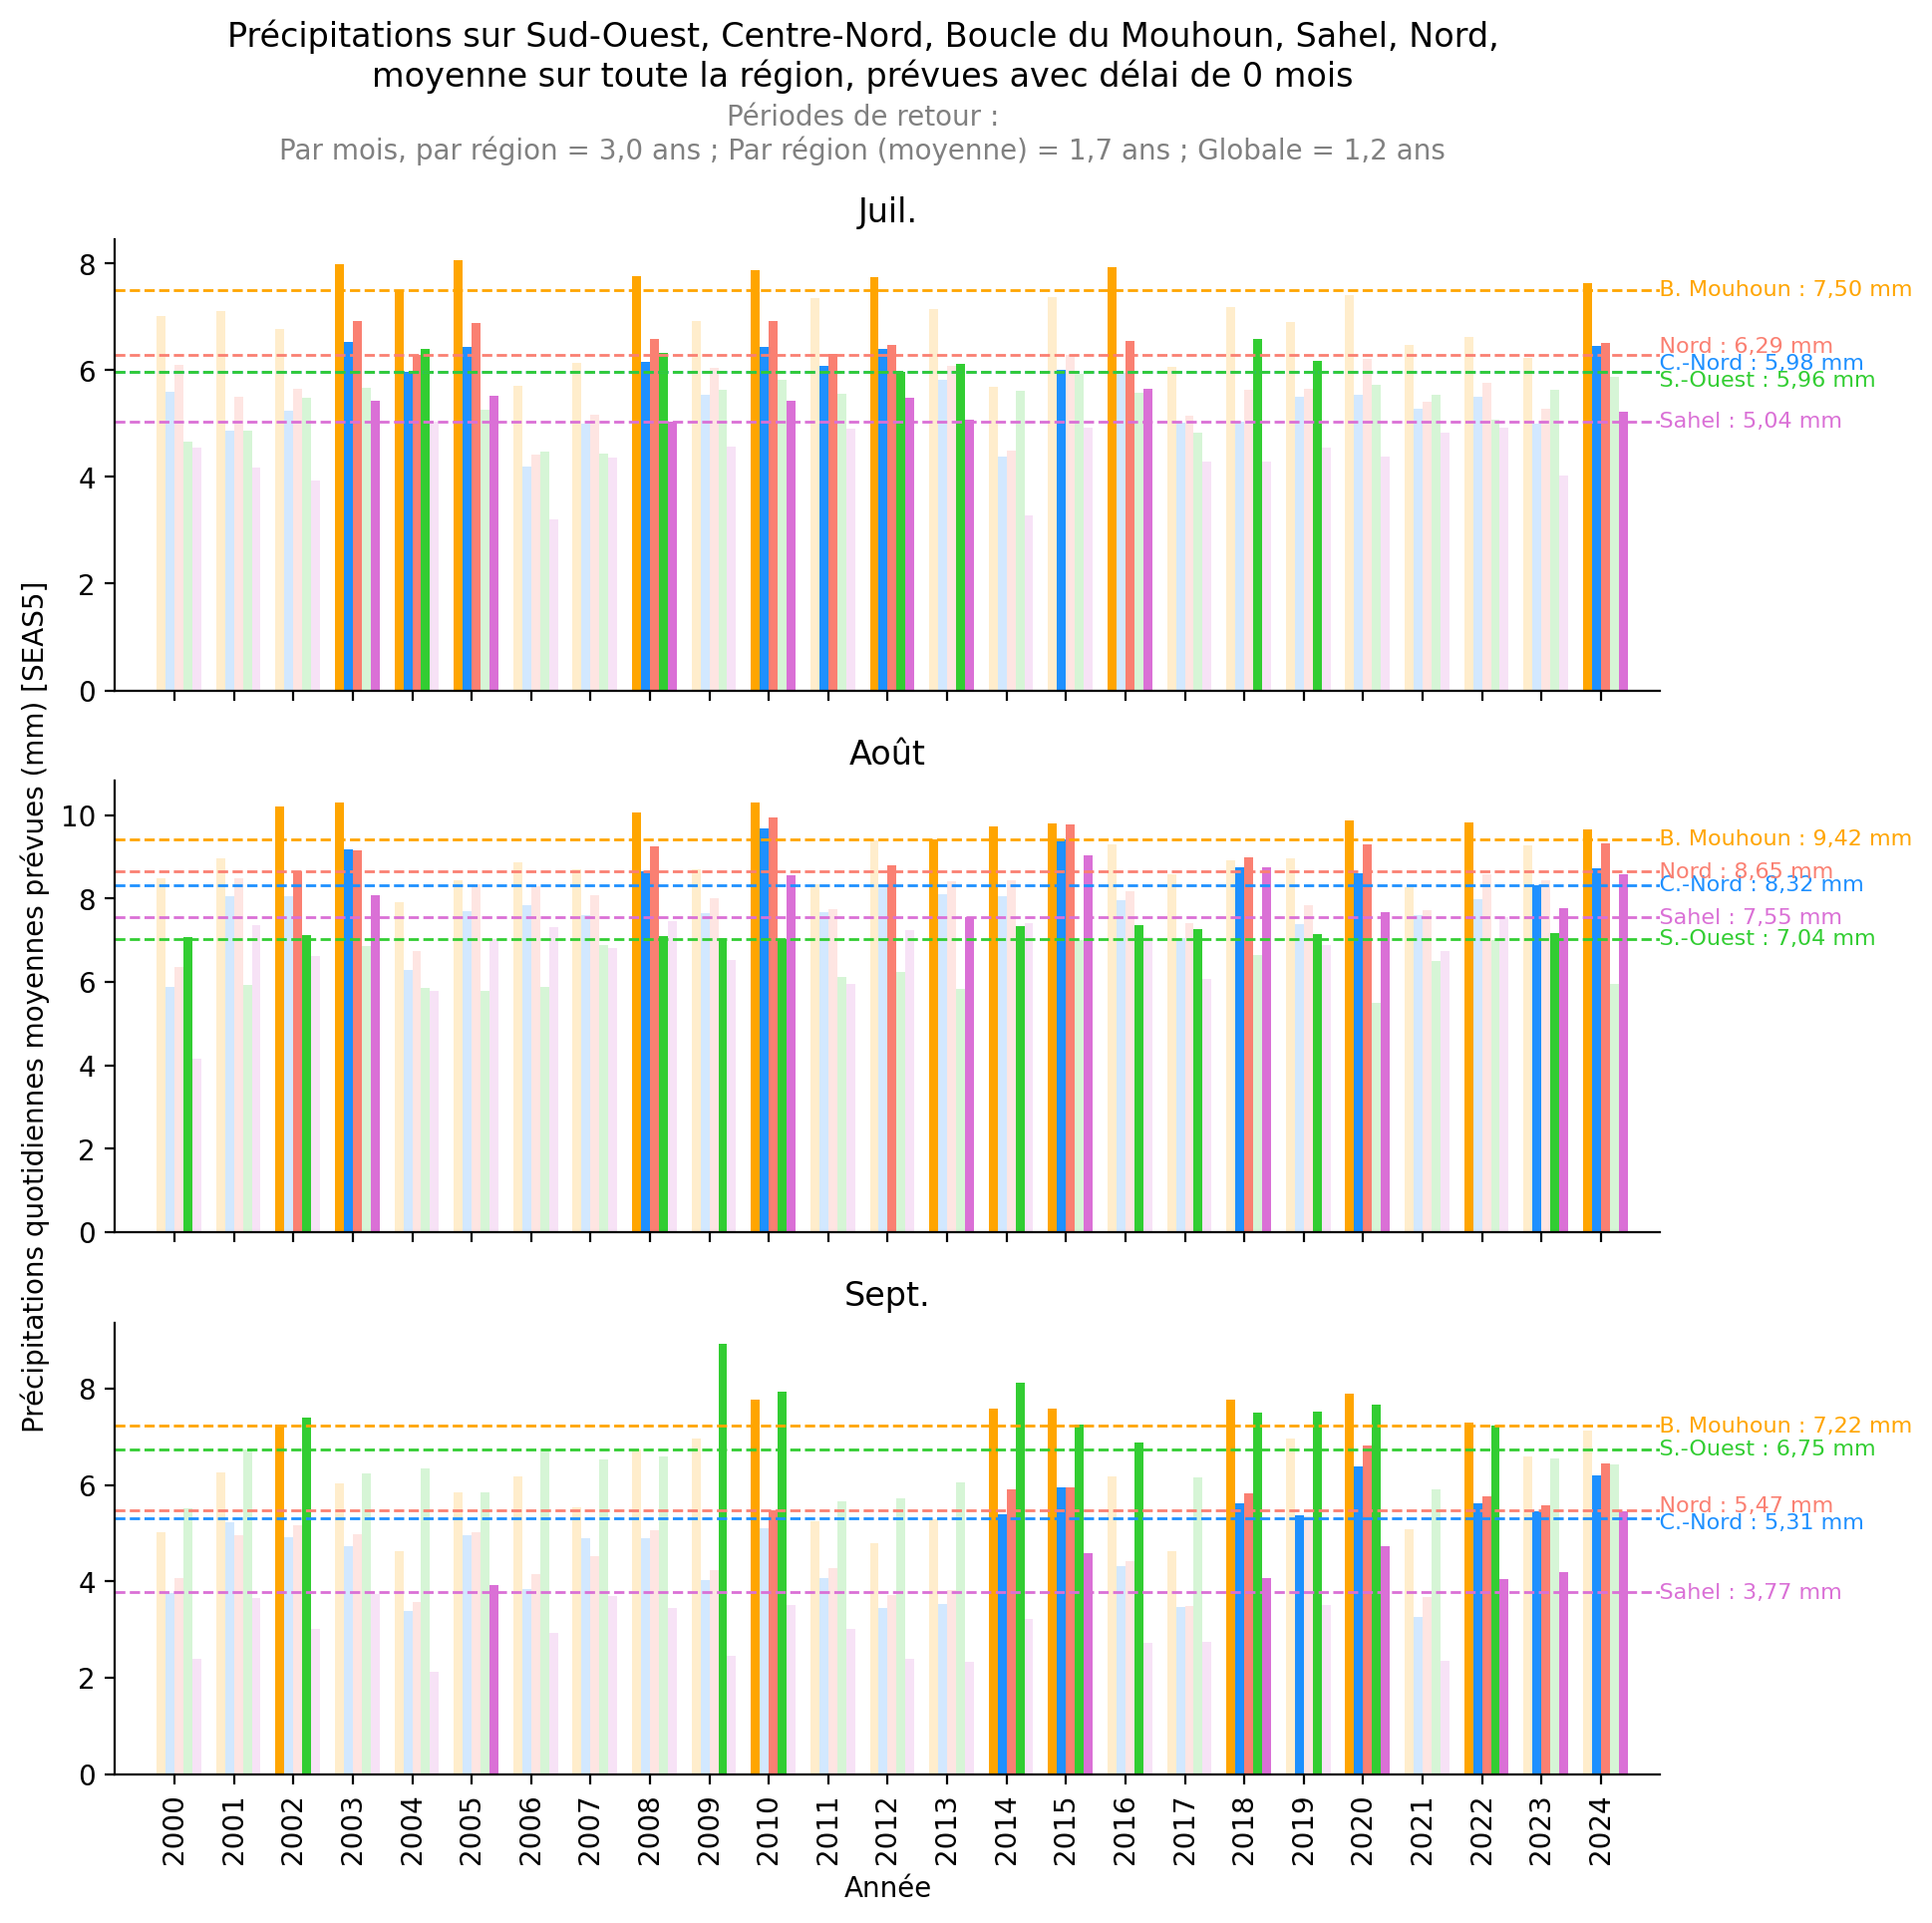

In [36]:
min_year = 2000

fig, axs = plt.subplots(nrows=3, figsize=(10, 10), sharex=True, dpi=200)

trig_colors = ["orange", "dodgerblue", "salmon", "limegreen", "orchid"]
vas = ["bottom", "top"]

df_plot = df_seas5_season.copy()
df_plot["trig"] = False

dicts = []
for i, (month, group) in enumerate(df_plot.groupby("month")):
    group = group.sort_values("mean_rp").copy()
    ax = axs[i]

    for j, (name, name_group) in enumerate(group.groupby("short_name")):
        color = trig_colors[j]
        thresh = np.interp(rp_ind, name_group["mean_rp"], name_group["mean"])
        name_group["trig"] = name_group["mean"] >= thresh

        # set triggered years for later per-region rp calculation
        df_plot.loc[
            (df_plot["mean"] >= thresh)
            & (df_plot["short_name"] == name)
            & (df_plot["month"] == month),
            "trig",
        ] = True

        name_group_plot = name_group[
            name_group["year"] >= min_year
        ].sort_values("year")

        x = np.arange(len(name_group_plot.index))
        bar_width = 0.15
        values = name_group_plot["mean"]
        offset = (j - 1.5) * bar_width

        # Set alpha based on threshold comparison
        alphas = name_group_plot["trig"].apply(lambda v: 1 if v else 0.2)

        # Plot individual bars with varying alpha
        for xi, yi, alpha in zip(x, values, alphas):
            ax.bar(xi + offset, yi, width=bar_width, color=color, alpha=alpha)

        ax.axhline(thresh, color=color, linestyle="--", linewidth=1)
        annotation = f"    {name} : " + f"{thresh:.2f} mm".replace(".", ",")
        y_adj = 0
        if month == 7:
            if name in ["C.-Nord", "Nord"]:
                y_adj = 0.15
            if name == "S.-Ouest":
                y_adj = -0.15
        if month == 9:
            if name == "Nord":
                y_adj = 0.1
            if name == "C.-Nord":
                y_adj = -0.1

        ax.annotate(
            annotation,
            (len(name_group_plot) - 0.5, thresh + y_adj),
            va="center",
            color=color,
            fontsize=8,
        )
        dicts.append(
            {
                "month": month,
                "pcode": name_group.iloc[0]["pcode"],
                "thresh": thresh,
            }
        )

    ax.set_xticks(x)
    ax.set_xlim((-1, len(name_group_plot)))
    ax.set_xticklabels(name_group_plot["year"], rotation=90)
    ax.set_title(FRENCH_MONTHS[calendar.month_abbr[month]].capitalize())

    if i == 1:
        ax.set_ylabel(
            "Précipitations quotidiennes moyennes prévues (mm) [SEAS5]"
        )

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

rp_region = (total_years + 1) / df_plot[df_plot["trig"]].groupby("name")[
    "year"
].nunique().mean()
rp_com = (total_years + 1) / df_plot[df_plot["trig"]]["year"].nunique()

axs[-1].set_xlabel("Année")

fig.suptitle(
    f"Précipitations sur {names_str},\nmoyenne sur toute la région, prévues avec délai de 0 mois\n",
    y=0.99,
)

rp_str = (
    "Périodes de retour :\n"
    f"Par mois, par région = {rp_ind:.1f} ans ; "
    f"Par région (moyenne) = {rp_region:.1f} ans ; "
    f"Globale = {rp_com:.1f} ans"
).replace(".", ",")

fig.text(
    0.5,
    0.92,
    rp_str,
    ha="center",
    fontsize=10,
    color="gray",
)

In [37]:
df_threshs = pd.DataFrame(dicts)

In [38]:
df_threshs

,month,pcode,thresh
0,7,BF46,7.502923
1,7,BF49,5.976226
2,7,BF54,6.292341
3,7,BF57,5.959127
4,7,BF56,5.037205
5,8,BF46,9.420354
6,8,BF49,8.317236
7,8,BF54,8.645514
8,8,BF57,7.035980
9,8,BF56,7.551833


## Monitoring

Plotting the values from 2026 for monitoring. Thresholds are unchanged from
the 2025 framework (calculated above, using years up to 2024).

In [39]:
df_seas5_grouped["issued_date"].max()

Timestamp('2025-09-01 00:00:00')

In [40]:
df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == "2026-07-01")
    & (df_seas5_grouped["issued_date"] == "2026-07-01")
]

,name,pcode,valid_date,issued_date,mean
3737,Boucle du Mouhoun,BF46,2025-09-01,2025-09-01,6.644838
7496,Centre-Nord,BF49,2025-09-01,2025-09-01,5.146989
11255,Nord,BF54,2025-09-01,2025-09-01,5.555063
15014,Sahel,BF56,2025-09-01,2025-09-01,4.127092
18773,Sud-Ouest,BF57,2025-09-01,2025-09-01,6.327030


In [41]:
df_seas5_season_recent = df_seas5_grouped[
    (df_seas5_grouped["valid_date"] == df_seas5_grouped["issued_date"])
    & (df_seas5_grouped["valid_date"].dt.month.isin(season_months))
].copy()
df_seas5_season_recent["year"] = df_seas5_season_recent["valid_date"].dt.year
df_seas5_season_recent["month"] = df_seas5_season_recent["valid_date"].dt.month
df_seas5_season_recent = df_seas5_season_recent.drop(
    columns=["valid_date", "issued_date"]
)
df_seas5_season_recent["short_name"] = df_seas5_season_recent["name"].replace(
    short_names
)

Text(0.5, 0.92, 'Périodes de retour :\nPar mois, par région = 3,0 ans ; Par région (moyenne) = 1,6 ans ; Globale = 1,2 ans')

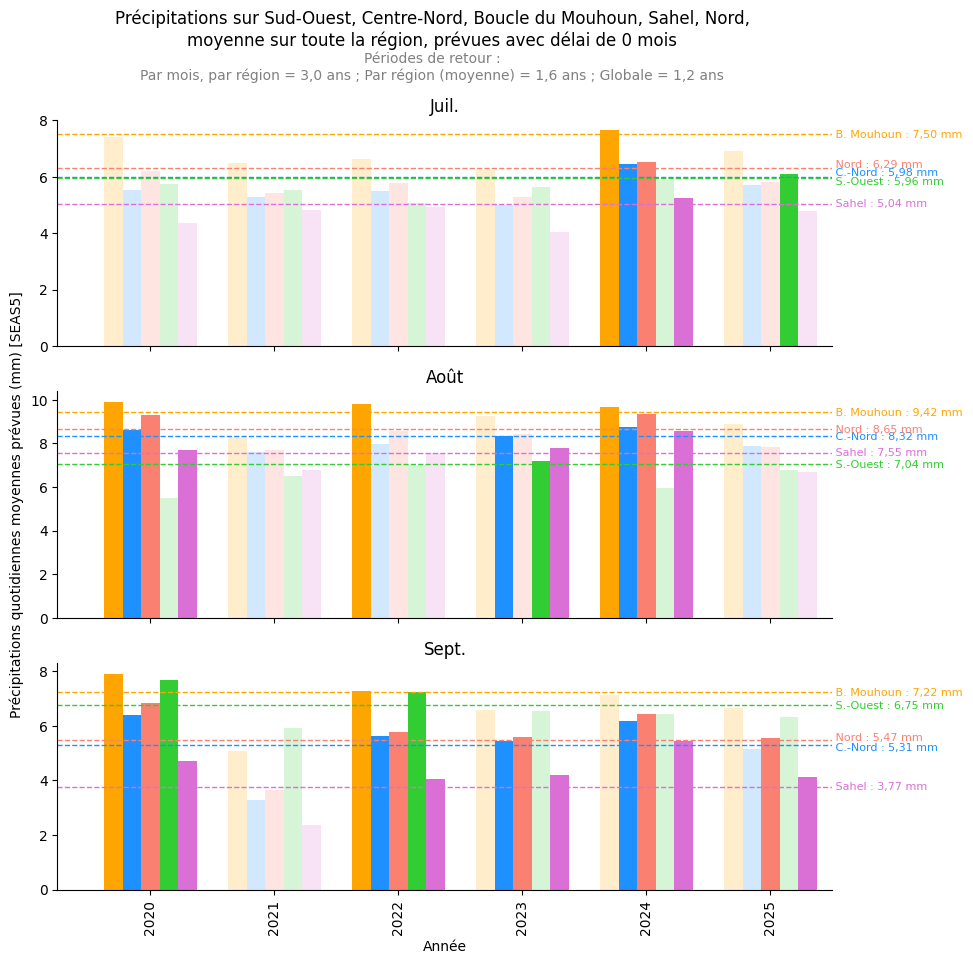

In [50]:
min_year = 2020

fig, axs = plt.subplots(nrows=3, figsize=(10, 10), sharex=True, dpi=100)

trig_colors = ["orange", "dodgerblue", "salmon", "limegreen", "orchid"]
vas = ["bottom", "top"]

df_plot = df_seas5_season_recent.copy()
df_plot["trig"] = False

years = range(min_year, df_plot["year"].max() + 1)

dicts = []
for i, (month, group) in enumerate(df_plot.groupby("month")):
    ax = axs[i]

    for j, (name, name_group) in enumerate(group.groupby("short_name")):
        color = trig_colors[j]
        pcode = name_group.iloc[0]["pcode"]
        thresh = df_threshs[
            (df_threshs["pcode"] == pcode) & (df_threshs["month"] == month)
        ].iloc[0]["thresh"]
        name_group["trig"] = name_group["mean"] >= thresh

        # set triggered years for later per-region rp calculation
        df_plot.loc[
            (df_plot["mean"] >= thresh)
            & (df_plot["short_name"] == name)
            & (df_plot["month"] == month),
            "trig",
        ] = True

        name_group_plot = name_group[
            name_group["year"] >= min_year
        ].sort_values("year")

        x = np.arange(len(name_group_plot.index))
        bar_width = 0.15
        values = name_group_plot["mean"]
        offset = (j - 2) * bar_width

        # Set alpha based on threshold comparison
        alphas = name_group_plot["trig"].apply(lambda v: 1 if v else 0.2)

        # Plot individual bars with varying alpha
        for xi, yi, alpha in zip(x, values, alphas):
            ax.bar(xi + offset, yi, width=bar_width, color=color, alpha=alpha)

        ax.axhline(thresh, color=color, linestyle="--", linewidth=1)
        annotation = f" {name} : " + f"{thresh:.2f} mm".replace(".", ",")
        y_adj = 0
        if month == 7:
            if name in ["C.-Nord", "Nord"]:
                y_adj = 0.15
            if name == "S.-Ouest":
                y_adj = -0.15
        if month == 9:
            if name == "Nord":
                y_adj = 0.1
            if name == "C.-Nord":
                y_adj = -0.1

        ax.annotate(
            annotation,
            (len(years) - 0.5, thresh + y_adj),
            va="center",
            color=color,
            fontsize=8,
        )
        dicts.append(
            {
                "month": month,
                "pcode": name_group.iloc[0]["pcode"],
                "thresh": thresh,
            }
        )

    ax.set_xticks(range(len(years)))
    ax.set_xlim((-0.75, len(years) - 0.5))
    ax.set_xticklabels(years, rotation=90)
    ax.set_title(FRENCH_MONTHS[calendar.month_abbr[month]].capitalize())

    if i == 1:
        ax.set_ylabel(
            "Précipitations quotidiennes moyennes prévues (mm) [SEAS5]"
        )

    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

rp_region = (total_years + 1) / df_plot[df_plot["trig"]].groupby("name")[
    "year"
].nunique().mean()
rp_com = (total_years + 1) / df_plot[df_plot["trig"]]["year"].nunique()

axs[-1].set_xlabel("Année")

fig.suptitle(
    f"Précipitations sur {names_str},\nmoyenne sur toute la région, prévues avec délai de 0 mois\n",
    y=0.99,
)

rp_str = (
    "Périodes de retour :\n"
    f"Par mois, par région = {rp_ind:.1f} ans ; "
    f"Par région (moyenne) = {rp_region:.1f} ans ; "
    f"Globale = {rp_com:.1f} ans"
).replace(".", ",")

fig.text(
    0.5,
    0.92,
    rp_str,
    ha="center",
    fontsize=10,
    color="gray",
)